# Limits of K-means clustering

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
clr = ['#ff0000', '#008000']

In [2]:
N = 40  # Number of points
K = 2   # Number of classes

In [3]:
def plotkmeans(X, fname):
    
    kmeans = KMeans(n_clusters=K, n_init=1, max_iter=1).fit(X)
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    
    colors = np.where(labels==0, clr[0], clr[1])

    fig, ax = plt.subplots(1, 1, figsize=(15,3))
    plt.scatter(X[:,0], X[:,1], c=colors)
    plt.scatter(centroids[:,0], centroids[:,1], c='k', marker='x', s=100)
    plt.xlim([-15,15])
    plt.ylim([-3,3])
    plt.xticks([])
    plt.yticks([])
    ax.set_aspect('equal')
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

## Spherical clusters

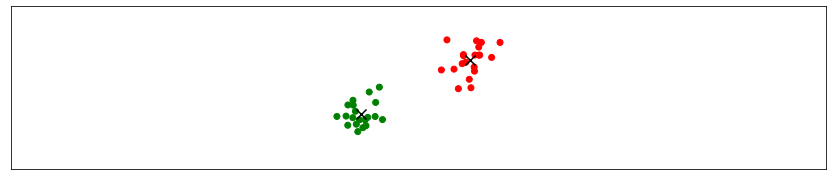

In [4]:
X = np.zeros((N,2))
X[:N//2,0] = np.random.normal(-2, .5, size=N//2)
X[:N//2,1] = np.random.normal(-1, .5, size=N//2)
X[N//2:,0] = np.random.normal( 2, .5, size=N//2)
X[N//2:,1] = np.random.normal( 1, .5, size=N//2)

plotkmeans(X, "kmeans-ok.svg")

## Non-spherical clusters

None


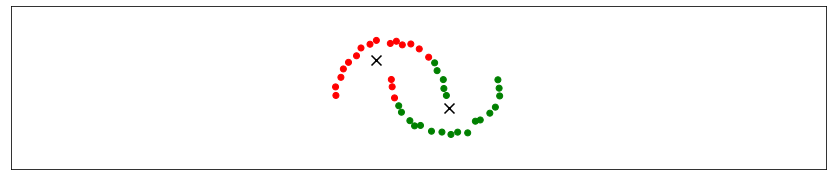

In [5]:
X = np.zeros((N,2))
t = np.linspace(0, np.pi, N//2)
X[:N//2,0] =  -1 + 2*np.cos(t)
X[:N//2,1] = -.3 + 2*np.sin(t)
X[N//2:,0] =   1 + 2*np.cos(t)
X[N//2:,1] =  .3 - 2*np.sin(t)
X += np.random.normal(0, .05, size=X.shape)

print(np.random.seed())

plotkmeans(X, "kmeans-croissants.svg")

## Outliers

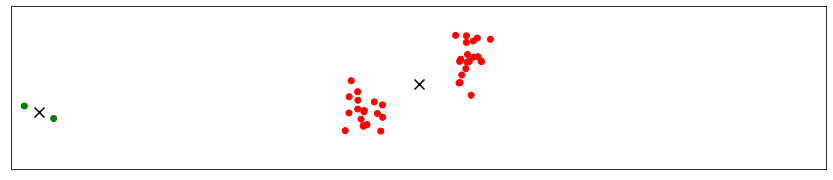

In [6]:
X = np.zeros((N,2))
X[:N//2,0] = np.random.normal(-2, .5, size=N//2)
X[:N//2,1] = np.random.normal(-1, .5, size=N//2)
X[N//2:,0] = np.random.normal( 2, .5, size=N//2)
X[N//2:,1] = np.random.normal( 1, .5, size=N//2)
X[:2,0] = np.random.normal(-14, 1, size=2)

plotkmeans(X, "kmeans-outliers.svg")